<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

TARGET_COL = "diabetes_label"

FEATURE_COLS_T1 = ["RIDAGEYR", "RIAGENDR", "RIDRETH3", "BMXBMI", "BMXWAIST", "BPXSY_mean", "BPXDI_mean"]
FEATURE_COLS_T2 = FEATURE_COLS_T1 + ["LBXTC", "LBXTR", "LBXSCR", "LBXSUA", "LBXSBU"]
FEATURE_COLS_T3 = FEATURE_COLS_T2 + [
    "LBXSATSI", "LBXSASSI", "LBXSTP", "LBXSAL", "LBXSCA",
    "LBXSPH", "LBXSNASI", "LBXSKSI", "LBXSGB", "LBXSC3SI"
]
ALL_FEATURE_COLS = FEATURE_COLS_T3

df = dataset.dropna(subset=ALL_FEATURE_COLS + [TARGET_COL]).copy()
print(f"Dataset shape: {df.shape}")

Dataset shape: (6045, 30)


In [3]:
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n_samples, n_features = X.shape
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        cov = (Xc.T @ Xc) / (n_samples - 1)
        eigvals, eigvecs = np.linalg.eigh(cov)
        order   = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]
        components = eigvecs.T
        max_abs    = np.argmax(np.abs(components), axis=1)
        signs      = np.sign(components[np.arange(components.shape[0]), max_abs])
        components = components * signs[:, None]
        k = self.n_components if self.n_components is not None else n_features
        total_var = eigvals.sum()
        self.components_               = components[:k]
        self.explained_variance_       = eigvals[:k]
        self.explained_variance_ratio_ = eigvals[:k] / total_var
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [4]:
scaler    = StandardScaler()
X_cluster = scaler.fit_transform(df[ALL_FEATURE_COLS])

pca_full = PCA().fit(X_cluster)
pca_2d   = PCA(n_components=2).fit(X_cluster)
X_2d     = pca_2d.transform(X_cluster)

print(f'PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Cumulative (PC1+PC2): {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

PC1: 15.2%
PC2: 10.5%
Cumulative (PC1+PC2): 25.7%


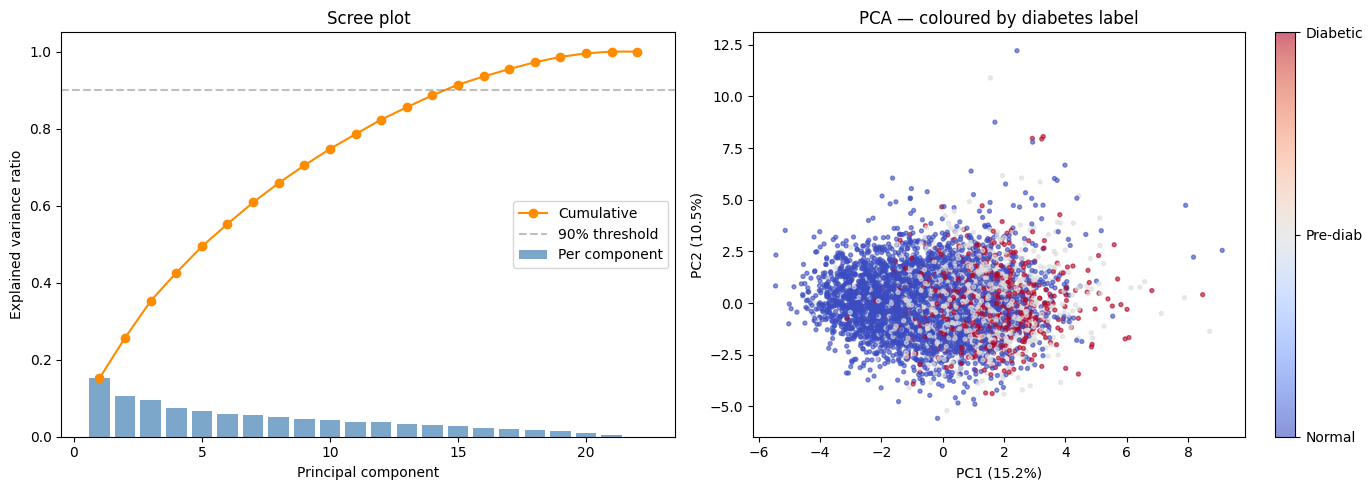

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ratios = pca_full.explained_variance_ratio_
cum    = np.cumsum(ratios)
axes[0].bar(range(1, len(ratios)+1), ratios, color='steelblue', alpha=0.7, label='Per component')
axes[0].plot(range(1, len(cum)+1), cum, 'o-', color='darkorange', label='Cumulative')
axes[0].axhline(0.9, ls='--', color='gray', alpha=0.5, label='90% threshold')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')
axes[0].legend()

# Scatter coloured by diabetes label
sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=df[TARGET_COL], cmap='coolwarm', s=8, alpha=0.6)
axes[1].set_title('PCA — coloured by diabetes label')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
cbar = plt.colorbar(sc, ax=axes[1], ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Normal', 'Pre-diab', 'Diabetic'])

plt.tight_layout()
plt.show()

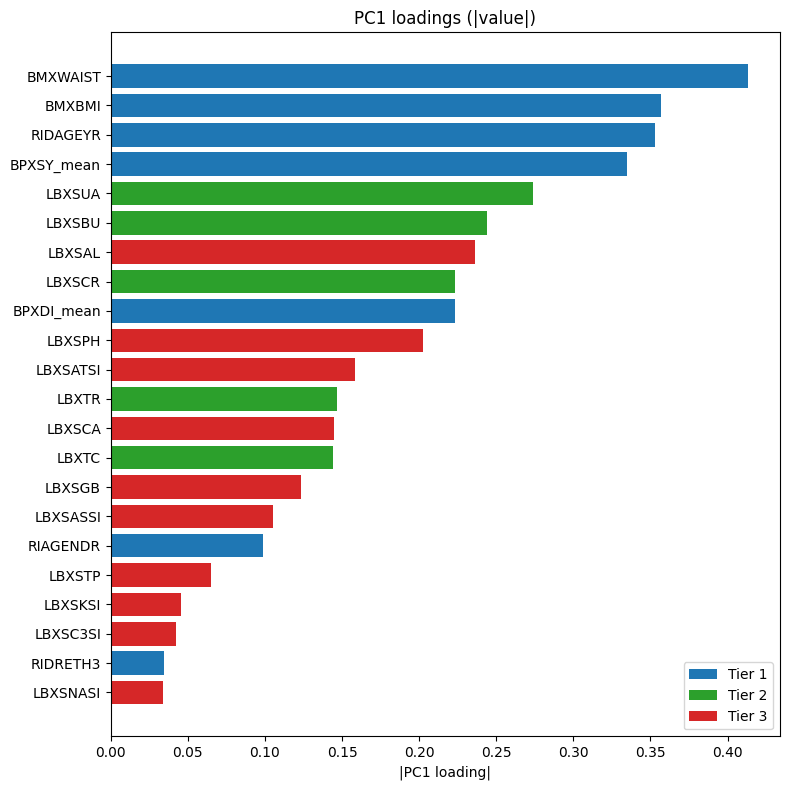

Top 5 features by |PC1 loading|:
   feature    value   tier
  BMXWAIST 0.413309 Tier 1
    BMXBMI 0.356735 Tier 1
  RIDAGEYR 0.353004 Tier 1
BPXSY_mean 0.334541 Tier 1
    LBXSUA 0.273496 Tier 2


In [8]:
from matplotlib.patches import Patch
feature_to_tier = {}
for f in ALL_FEATURE_COLS:
    if f in FEATURE_COLS_T1:
        feature_to_tier[f] = 'Tier 1'
    elif f in FEATURE_COLS_T2:
        feature_to_tier[f] = 'Tier 2'
    else:
        feature_to_tier[f] = 'Tier 3'

tier_colors = {'Tier 1': '#1f77b4', 'Tier 2': '#2ca02c', 'Tier 3': '#d62728'}

loading_df = pd.DataFrame({
    'feature': ALL_FEATURE_COLS,
    'value':   np.abs(pca_full.components_[0]),
    'tier':    [feature_to_tier[f] for f in ALL_FEATURE_COLS],
}).sort_values('value', ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(loading_df['feature'], loading_df['value'],
        color=[tier_colors[t] for t in loading_df['tier']])
ax.set_title('PC1 loadings (|value|)')
ax.set_xlabel('|PC1 loading|')
ax.legend(handles=[Patch(facecolor=c, label=t) for t, c in tier_colors.items()],
          loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 features by |PC1 loading|:')
print(loading_df.sort_values('value', ascending=False).head(5).to_string(index=False))